In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd

In [2]:
%%time

ddir = 'data/'
_df = pd.read_csv(os.path.join(ddir,'chembl_valid_atom_counts.csv'),
                 usecols=['smiles','n_atoms'])
display(_df)

,smiles,n_atoms
0,C,1
1,CC,2
2,CO,2
3,CF,2
4,CI,2
...,...,...
1502534,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...,651
1502535,Cc1cn(C2CN(P(=O)(OCC3CN(P(=O)(OCC4CNCC(n5cnc6c...,678
1502536,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...,674
1502537,C=C1NC(=O)C(C)=CN1C1CC(OP(=O)(O)OCC2OC(n3cnc4c...,675


CPU times: user 935 ms, sys: 96.6 ms, total: 1.03 s
Wall time: 1.03 s


573978


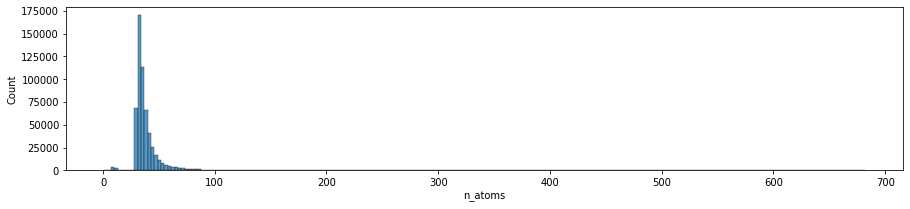

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df = _df[(_df.n_atoms >= 30) | (_df.n_atoms <= 10)]
print(len(df))
plt.figure(figsize=(15,3))
# sns.countplot(data=df_outter, x='n_atoms')
sns.histplot(df, x='n_atoms',binwidth=3)
plt.show()

In [4]:
WHICH = 'test'
N = 1000

In [5]:
from utilities.data_utils import get_anc_to_aug_map
from tqdm import tqdm
import random
random.seed(666)

idc = random.sample(range(len(df)), N)
df = df.iloc[idc]

if WHICH=='test':
    anc_to_augs = get_anc_to_aug_map(df)
    
df_augs = []
df_ancs = []

for i,(anc_smi,augs) in tqdm(enumerate(anc_to_augs.items()),
                             total=len(anc_to_augs)):
    
    ser = pd.Series({'smiles':anc_smi}) 
    df_ancs.append(ser)
    
    for aug_smi in augs:
        ser = pd.Series({'anc_idx': i,'smiles':aug_smi}) 
        df_augs.append(ser)
    
df_augs = pd.DataFrame(df_augs)
df_anc = pd.DataFrame(df_ancs)

df_augs.to_csv(f'data/model_ready/01/{WHICH}/augmented_smiles_ood.csv',index=False)
df_anc.to_csv(f'data/model_ready/01/{WHICH}/anchor_smiles_ood.csv',index=False)

100%|██████████| 1000/1000 [00:01<00:00, 944.42it/s]
